IMPORTING REQUIRED MODULES

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import regex as re

# MANUAL INSPECTION
DATA DIRTINESS
- age has missing values -5 rows(on programmatic assessment)
- region has missing values -3 rows (on programmatic assessment)

In [ ]:
df=pd.read_csv(r'insurance_data.csv')

In [ ]:
df.info()

WE COULD HAVE CHANGED THE DATATYPE OF AGE COLUMN BUT SINCE SOME VALUES ARE MISSING WE CANNOT FILL IT UP ALTHOUGH WE CAN DROP IT AS ONLY 5 ROWS ARE THERE 

# CATEGORIZING THE COLUMNS
numerical-index,patientid,age,bmi,bloodpressure,claim

categorical-gender,diabetic,smoker,region,children

In [ ]:
df['children'].value_counts()

In [ ]:
df.duplicated().sum()

# UNIVARIATE ANALYSIS ON AGE COLUMN
## conclusions
- all 18 year old (min age) were males
- all 60 year olds(max age) were females
- age column is almost normally distributed
- age has no outlier
- all 53 year olds(the grp with least members) were females
- 5 age rows have no values

In [ ]:
df['age'].describe()

In [ ]:
df.query("age==18")
#all 18 year olds were male

In [ ]:
df.query("age==60")
#all 60 year(max age) olds were females

In [ ]:
df['age'].skew() #almost normally distributed

In [ ]:
df['age'].plot(kind='hist')

In [ ]:
sns.kdeplot(data=df,x='age')

In [ ]:
sns.boxplot(data=df, y='age')
plt.show()

In [ ]:
sns.violinplot(data=df, y='age')
plt.show()

In [ ]:
df['age'].isnull().sum()

In [ ]:
df['age'].value_counts()

In [ ]:
df.query('age==53')
#this is the age with least members and all are females

In [ ]:
df.query('age==38')

In [ ]:
df.query('age==47')

# UNIVARIATE ANALYSIS ON BMI COLUMN
## CONCLUSION
- THE PERSON WITH MAX BMI AND MIN BMI BOTH ARE MALES 
- THE DATA IS NORMALLY DISTRIBUTED
- THERE ARE SOME OUTLIERS
- NO NULL VALUES

In [ ]:
df['bmi'].describe()

In [ ]:
df.query('bmi==16')

In [ ]:
df.query('bmi==53.1')

In [ ]:
df['bmi'].plot(kind='hist')

In [ ]:
sns.kdeplot(data=df,x='bmi')

In [ ]:
df.bmi.skew()

In [ ]:
sns.boxplot(data=df,x='bmi')

In [ ]:
df.query('bmi>45')
#these are the outliers although they don't have any issues with them

In [ ]:
df['bmi'].value_counts()

In [ ]:
df.query('bmi==33.3')

In [ ]:
df['bmi'].duplicated().sum()

# UNIVARIATE ANALYSIS ON BLOODPRESSURE COLUMN
### CONCLUSIONS
- those with highest bloodpressure 140 had very high claims above 35k
- there were outliers above 118 bloodpressure and they also had very high claims
- the bloodpressure column is positively skewed

In [ ]:
df['bloodpressure'].describe()

In [ ]:
df.query('bloodpressure==80')

In [ ]:
df.query('bloodpressure==140')
#the people with 140 blood pressure had very high claims above 35k

In [ ]:
df['bloodpressure'].plot(kind='hist')

In [ ]:
sns.kdeplot(data=df,x='bloodpressure')

In [ ]:
sns.boxplot(data=df,y='bloodpressure')

In [ ]:
df.query('bloodpressure>118')
#there were outliers above 118 and all of them had very high claim

In [ ]:
df['bloodpressure'].skew()

In [ ]:
df['bloodpressure'].value_counts()

In [ ]:
df['bloodpressure'].isnull().sum()

# UNIVARIATE ANALYSIS ON CLAIM
### CONCLUSIONS
- the least claim is 1121.87 which is by a male
- the highest claim is by a female at 63770.43 who is a smoker
- the data is positively skewed
- there are outliers in this data i.e claims above 35k and on inspection we find that most of them were smokers only 3 weren't smokers and they were females (pid-->1210,1223)
- also when we check those claims above 75 percentile most of them were smokers 
- based on 25th percentile etc values we can create a new column were claim type such as high low etc could be created

In [159]:
df['claim'].describe()

count     1340.000000
mean     13252.745642
std      12109.609288
min       1121.870000
25%       4719.685000
50%       9369.615000
75%      16604.305000
max      63770.430000
Name: claim, dtype: float64

In [ ]:
df.query('claim==1121.87')

In [ ]:
df.query('claim==63770.43')

In [ ]:
df.claim.plot(kind='hist')

In [ ]:
df.claim.skew()

In [ ]:
sns.kdeplot(data=df,x='claim')

In [ ]:
sns.boxplot(data=df,y='claim')

In [ ]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

df.query('claim > 35000')

In [ ]:
df.claim.value_counts()

In [ ]:
df.claim.isnull().sum()

In [ ]:
df.query('claim>16604.305')['smoker'].value_counts()

In [ ]:
df.query('claim > 35000')['smoker'].value_counts()

# UNIVARIATE ANALYSIS ON CATEGORICAL COLUMNS

## UNIVARIATE ANALYSIS ON GENDER COLUMN
### CONCLUSION
- almost equal no of males and females
- we cannot access normality because there are only two entries

In [ ]:
df.gender.value_counts()

In [ ]:
df.gender.value_counts().plot(kind='bar')

In [ ]:
sns.kdeplot(df.gender.value_counts())

In [ ]:
sns.histplot(df['gender'].value_counts(), kde=True)

In [ ]:
df['gender'].value_counts().plot(kind='pie',autopct='%0.1f%%')

## UNIVARIATE ANALYSIS ON DIABETIC COLUMN
### CONCLUSION
- no null values and almost equal no of diabetic and non diabetic people

In [ ]:
df.diabetic.value_counts()

In [ ]:
df.diabetic.value_counts().plot(kind='bar')

In [ ]:
df['diabetic'].value_counts().plot(kind='pie',autopct='%0.1f%%')

In [ ]:
df.diabetic.isnull().sum()

## UNIVARIATE ANALYSIS ON SMOKER COLUMN
### CONCLUSION
- no null values 
- mostly non smokers are there in the dataset

In [ ]:
df.smoker.value_counts()

In [ ]:
df.smoker.isnull().sum()

In [ ]:
df.smoker.value_counts().plot(kind='bar')

In [ ]:
df.smoker.value_counts().plot(kind='pie',autopct='%0.1f%%')

## UNIVARIATE ANALYSIS ON REGION COLUMN
### CONCLUSION
- three values 
- there are four regions 
- southeast 33.1%
- northeast 17.3%
- southwest 23.5%
- northwest 26.1%

In [ ]:
df.region.isnull().sum()

In [ ]:
df.region.value_counts()

In [ ]:
df.region.value_counts().plot(kind='bar')

In [ ]:
df.region.value_counts().plot(kind='pie',autopct='%0.1f%%')

## UNIVARIATE ANALYSIS ON CHILDREN COLUMN
### CONCLUSION
- no null values
- positivily skewed
- mostly people with no children are there
# we can create a new column were a new column called family size
- where people with zero children are classified as single
- people with 1 or 2 children are classified as small family
- more than 2 is classified as large

In [ ]:
df.children.value_counts()

In [ ]:
df.children.value_counts().skew()

In [ ]:
df.children.value_counts().plot(kind='bar')

In [ ]:
df.children.value_counts().plot(kind='hist')

In [ ]:
df.children.value_counts().plot(kind='pie',autopct='%0.1f%%')

In [ ]:
df.children.isnull().sum()

# CREATING FAMILY SIZE COLUMN

In [214]:
def family_size(number):
    if number==0:
        return 'single'
    elif (number >=1) and (number <=2):
        return 'small'
    else:return 'large'

In [215]:
df['family_size']=df['children'].apply(family_size)

# CREATING INSURANCE TYPE COLUMN

In [160]:
def insurance_type(insurance):
    if insurance<1121.87:
        return 'low'
    elif (insurance>=1121.87) and (insurance<=4719.685):
        return 'medium'
    elif(insurance>4719.685) and (insurance<=9369.615):
        return 'high'
    elif(insurance>9369.615) and (insurance<=16604.305):
        return 'modhigh'
    else:return 'veryhigh'

In [161]:
df['insurance_type']=df['claim'].apply(insurance_type)

# BIVARIATE ANALYSIS

### age(numerical) vs claim(numerical)
- no strong correlation between the two

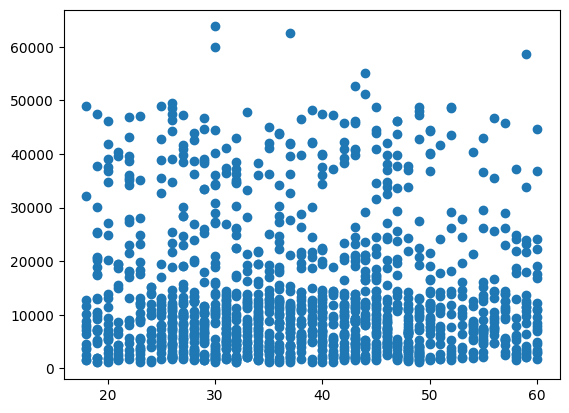

In [163]:
plt.scatter(x=df['age'],y=df['claim'])

<Axes: xlabel='age', ylabel='claim'>

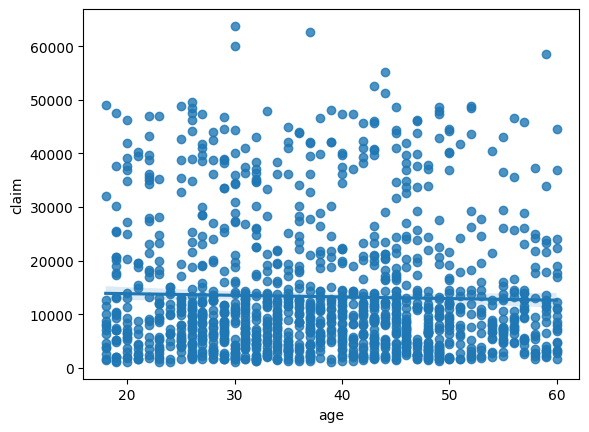

In [ ]:
sns.regplot(data=df,x=df['age'],y=df['claim'])
#There is no strong linear relationship visible between age and claim when looking at all customers together.

<Axes: xlabel='age', ylabel='claim'>

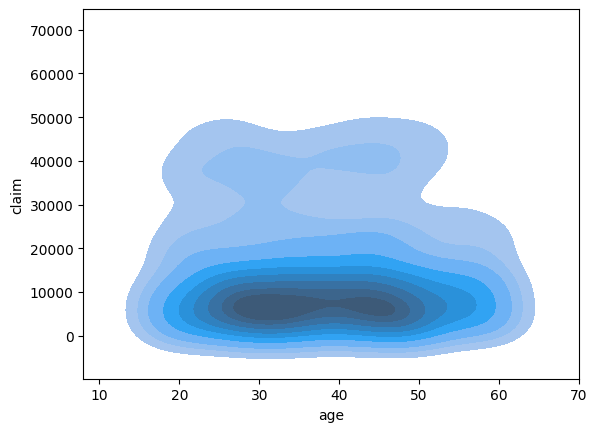

In [169]:
sns.kdeplot(data=df,x='age',y='claim',fill=True)


<Axes: xlabel='age', ylabel='claim'>

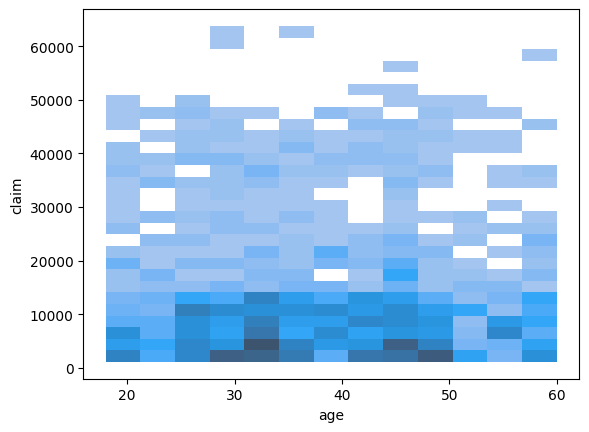

In [168]:
sns.histplot(data=df,x='age',y='claim')

In [171]:
df['age'].corr(df['claim'])
#neglidible co relation

np.float64(-0.027908809752189047)

### BIVARIATE ANALYSIS BETWEEN GENDER(categorical) AND CLAIM(numerical)
- "Claim distributions for males and females are broadly similar, although males appear to have a slightly wider spread and somewhat higher upper-range claims."

<Axes: xlabel='gender', ylabel='claim'>

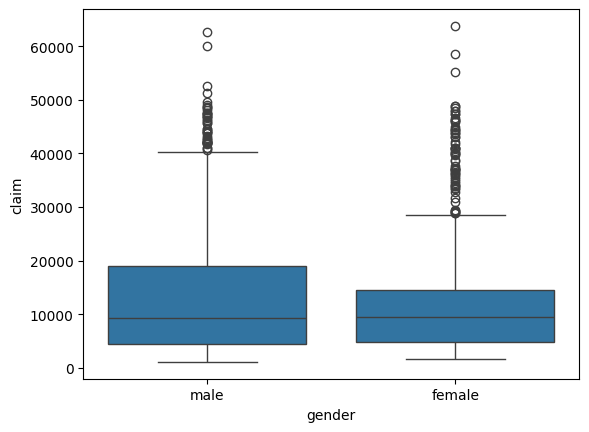

In [ ]:
sns.boxplot(data=df,x='gender',y='claim')
#"Claim distributions for males and females are broadly similar, although males appear to have a slightly wider spread and somewhat higher upper-range claims."

<Axes: xlabel='gender', ylabel='claim'>

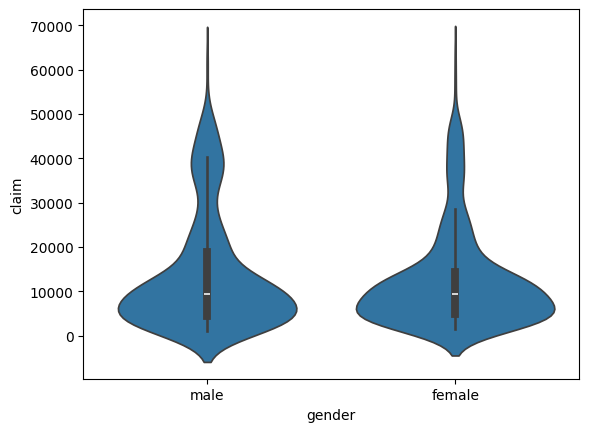

In [175]:
sns.violinplot(data=df,x='gender',y='claim')

<Axes: xlabel='gender', ylabel='claim'>

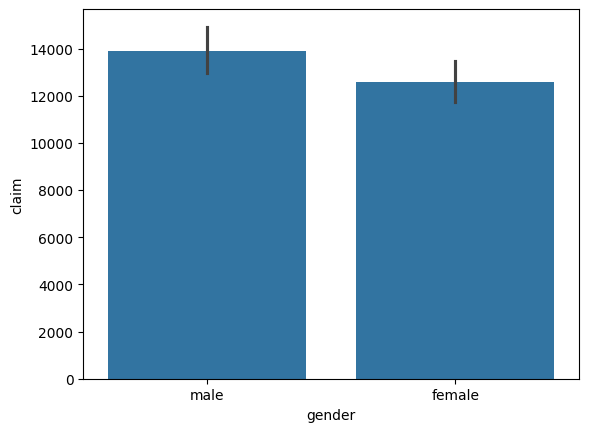

In [177]:
sns.barplot(data=df,x='gender',y='claim')

In [178]:
#fnc to create new column bmi grp
def bmi_grp(no):
    if no<18.5:
        return 'underweight'
    elif ( no >=18.5) and (no <=24.9):
        return 'normal'
    elif (no>=25) and (no<=29.9):
        return 'overweight'
    elif (no>=30) and (no<=34.9):
        return 'obese1'
    elif (no>=35) and (no<=39.9):
        return 'obese2'
    else:return 'obese3'

In [179]:
#creating new column
df['bmi_grp']=df['bmi'].apply(bmi_grp)

### BIVARIATE ANALYSIS BETWEEN bmi(numerical) AND CLAIM(numerical)
-- we find weak positive correlation

-- there are two density regions-->bmi 20 to 40 with claims rougly 2k to 15k and bmi roughly 30 to 50 with claims roughly 30k to 50k

<Axes: xlabel='bmi', ylabel='claim'>

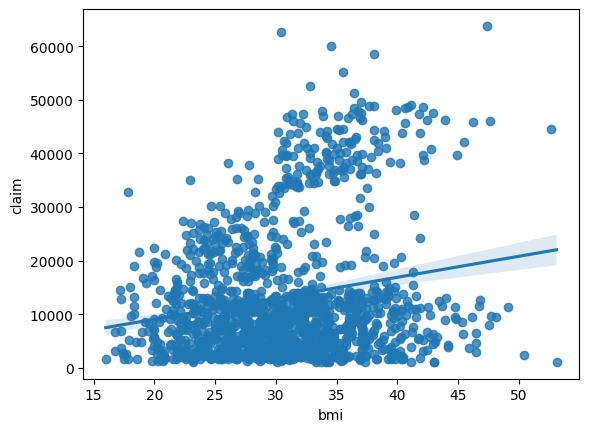

In [186]:
sns.regplot(data=df,x=df['bmi'],y=df['claim'])
#weak positive correlation

<Axes: xlabel='bmi', ylabel='claim'>

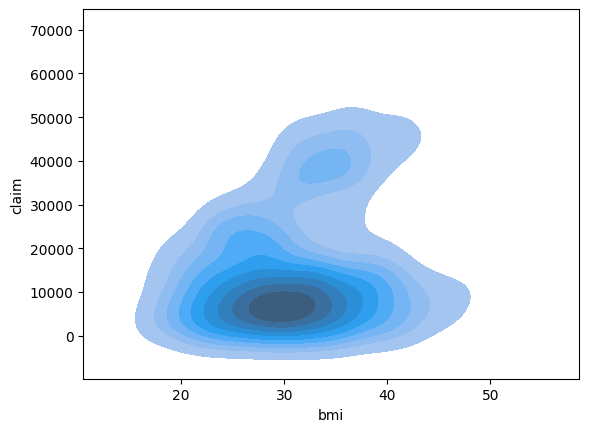

In [188]:
sns.kdeplot(data=df,x='bmi',y='claim',fill=True)
#we can see that there are two density regions-->bmi 20 to 40 with claims rougly 2k to 15k and bmi roughly 30 to 50 with claims roughly 30k to 50k

In [185]:
df['bmi'].corr(df['claim'])

np.float64(0.19740133652071148)

### BIVARIATE ANALYSIS BETWEEN bloodpressure(numerical) AND CLAIM(numerical)
- strong positive correlation

- #bp from 80 to 105 have claims bw 0 to 20k almost

In [ ]:
df['bloodpressure'].corr(df['claim'])
#strong positive correlation

np.float64(0.5313409750663161)

<Axes: xlabel='bloodpressure', ylabel='claim'>

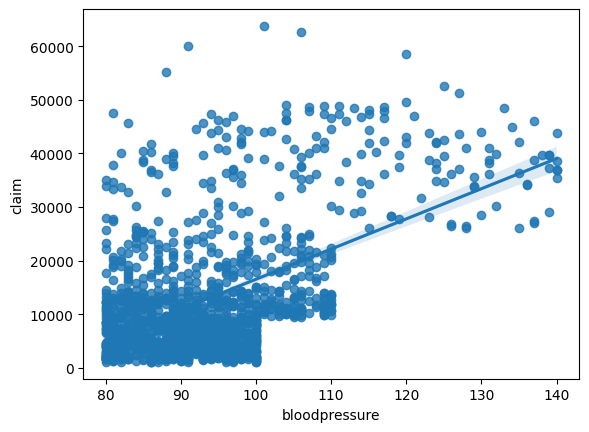

In [193]:
sns.regplot(data=df,x='bloodpressure',y='claim')

<Axes: xlabel='bloodpressure', ylabel='claim'>

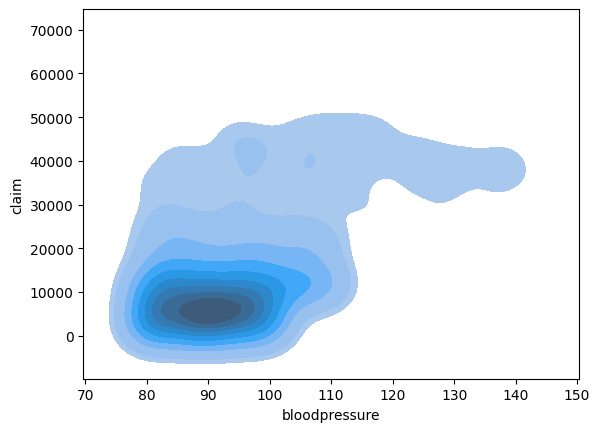

In [195]:
sns.kdeplot(data=df,x='bloodpressure',y='claim',fill=True)
#bp from 80 to 105 have claims bw 0 to 20k almost

In [196]:
# we wanted to create a new grp called blood pressure category but since only one type of pressure is given we would use quantiles
df['bp_group'] = pd.qcut(df['bloodpressure'],q=4,labels=['Low', 'Medium', 'High', 'Very High'])

# BIVARIATE ANALYSIS BW BP GRP AND CLAIM
- Low, Medium, and High BP groups all have numerous high-claim outliers.
- The median claim amount appears highest for the Very High BP group.
- Individuals in the Very High BP group tend to have substantially higher claim amounts than the other BP groups
- The Very High BP group contains a much smaller proportion of low-claim observations compared with the other BP groups
- The jump from high to very high is too much so investigate if very high bloodpressure have other things in common with other columns

<Axes: xlabel='bp_group', ylabel='claim'>

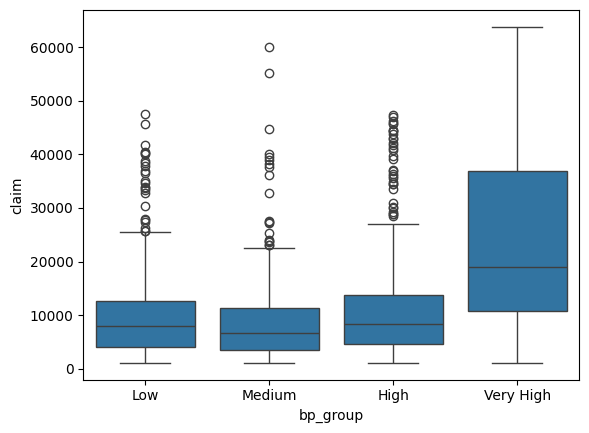

In [197]:
sns.boxplot(data=df,x='bp_group',y='claim')

<Axes: xlabel='bp_group', ylabel='claim'>

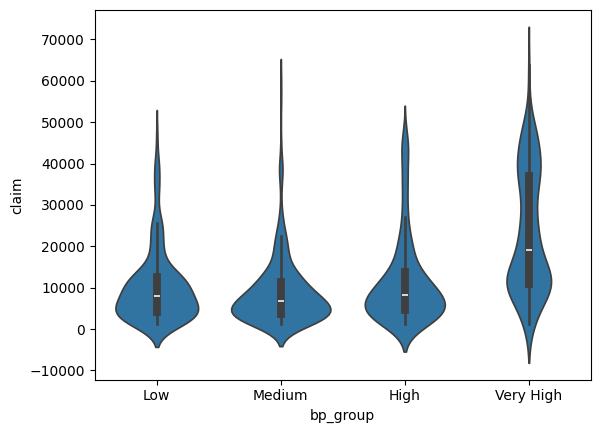

In [199]:
sns.violinplot(data=df,x='bp_group',y='claim')

## BIVARIATE ANALYSIS BW DIABETIC(CATEGORICAL) AND CLAIMS
- no strong relationship bw diabetic and claims

<Axes: xlabel='diabetic', ylabel='claim'>

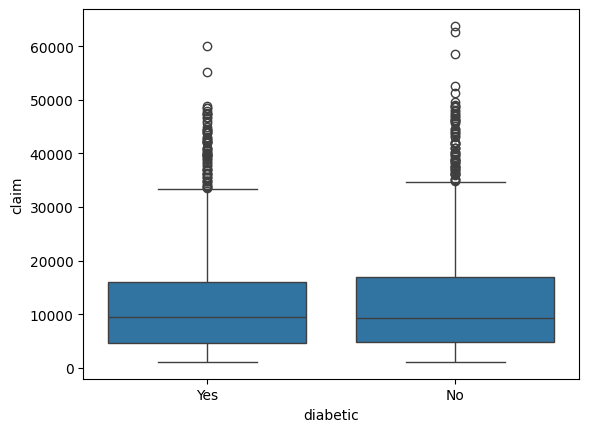

In [201]:
sns.boxplot(data=df,x='diabetic',y='claim')

<Axes: xlabel='diabetic', ylabel='claim'>

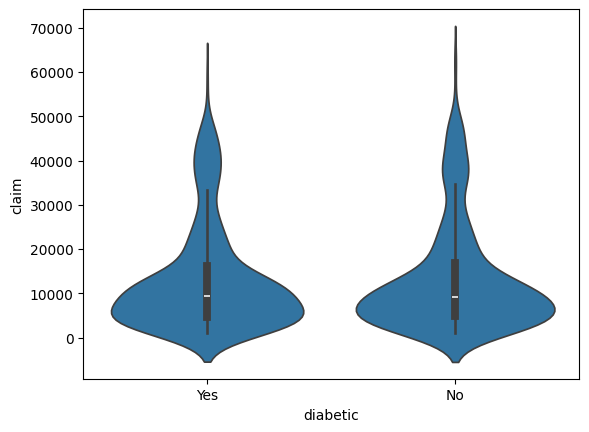

In [202]:
sns.violinplot(data=df,x='diabetic',y='claim')

# BIVARIATE ANALYSIS BETWEEN CHILDREN AND CLAIM
- negligible correlation
- we can see that from the patch people with zero to 3 children get claims bw o to 20k

<Axes: xlabel='children', ylabel='claim'>

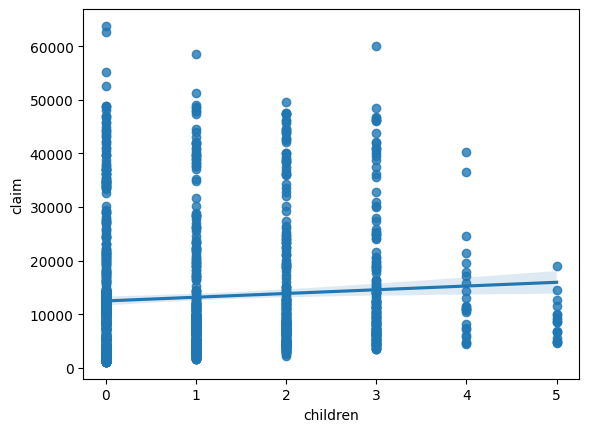

In [203]:
sns.regplot(data=df,x='children',y='claim')

<Axes: xlabel='children', ylabel='claim'>

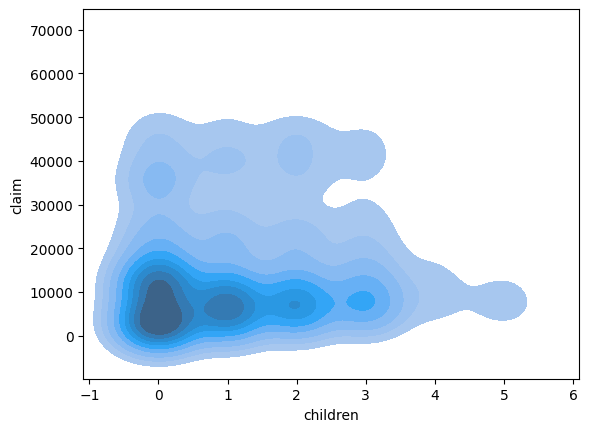

In [206]:
sns.kdeplot(data=df,x='children',y='claim',fill=True)
#we can see that from the patch people with zero to 3 children get claims bw o to 20k

In [208]:
df.children.corr(df['claim'])
#negligible relation

np.float64(0.06923287824477578)

# BIVARIATE ANALYSIS BETWEEN FAMILY SIZE AND CLAIM
- Claim distributions are broadly similar across family-size groups. Although large families exhibit a slightly higher median claim, the heavy overlap between distributions suggests that family size has only a weak relationship with claim amount.

<Axes: xlabel='family_size', ylabel='claim'>

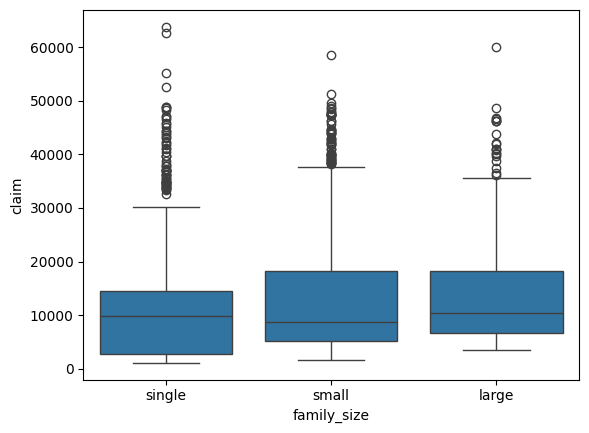

In [216]:
sns.boxplot(data=df,x='family_size',y='claim')

# BIVARIATE ANALYSIS BETWEEN SMOKER AND CLAIM
-Smoking status appears to be one of the strongest factors associated with insurance claims. Smokers exhibit substantially higher claim amounts than non-smokers, with a much higher median claim and an overall upward-shifted distribution. Although some non-smokers have high claims, the majority of non-smoker claims fall below 12,000, whereas smoker claims are concentrated at significantly higher values

<Axes: xlabel='smoker', ylabel='claim'>

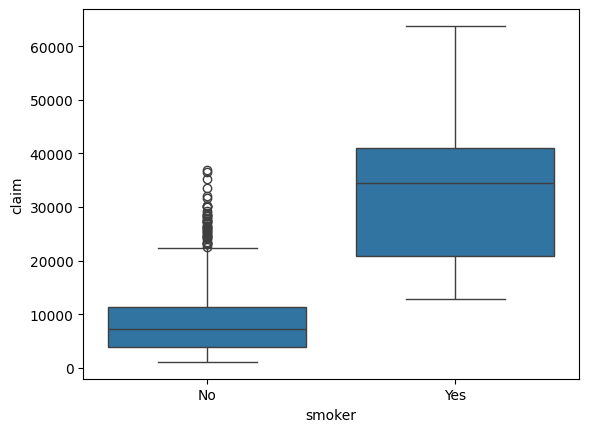

In [218]:
sns.boxplot(data=df,x='smoker',y='claim')

<Axes: xlabel='smoker', ylabel='claim'>

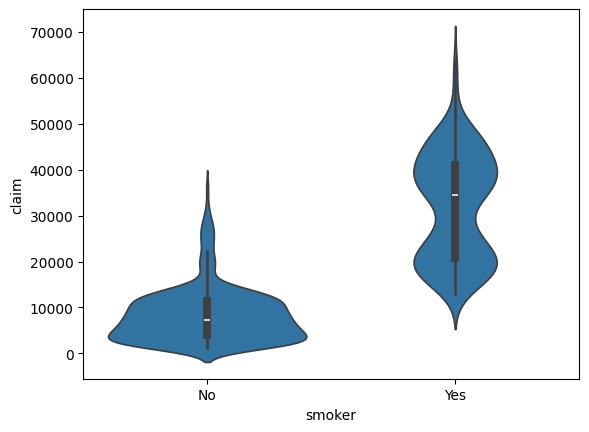

In [223]:
sns.violinplot(data=df,x='smoker',y='claim')

# BIVARIATE ANALYSIS BETWEEN REGION AND CLAIM
- Regional differences exist, with the Northeast showing the highest median claim but no strong indicator of claims

<Axes: xlabel='region', ylabel='claim'>

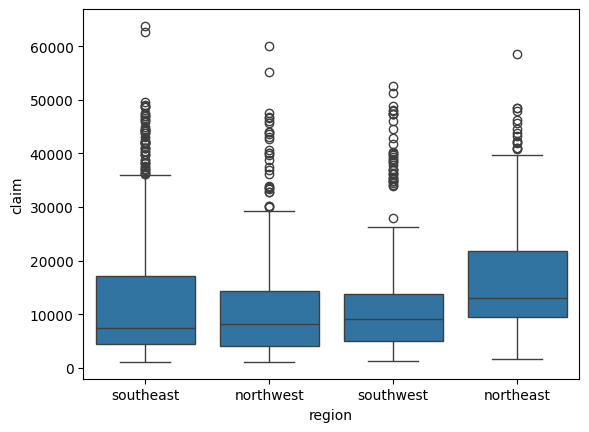

In [224]:
sns.boxplot(data=df,x='region',y='claim')

<Axes: xlabel='region', ylabel='claim'>

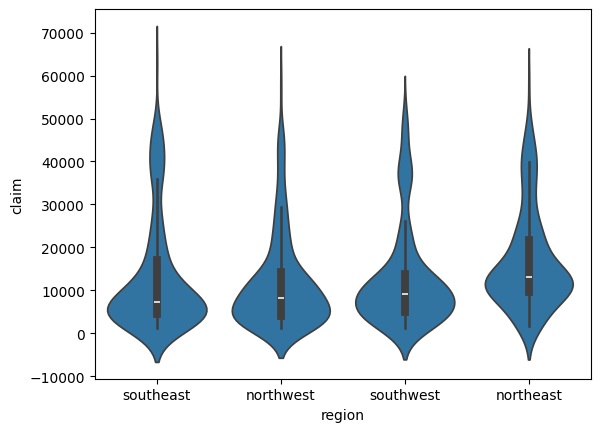

In [225]:
sns.violinplot(data=df,x='region',y='claim')

# BIVARIATE ANALYSIS BMI GRP REGION AND CLAIM
- MI category does not exhibit a dramatic effect on claim amount. However, Obese II and Obese III individuals tend to have higher median claims and greater variability than Normal or Underweight individuals. The substantial overlap among distributions suggests that BMI alone is not a strong determinant of claim amount

<Axes: xlabel='bmi_grp', ylabel='claim'>

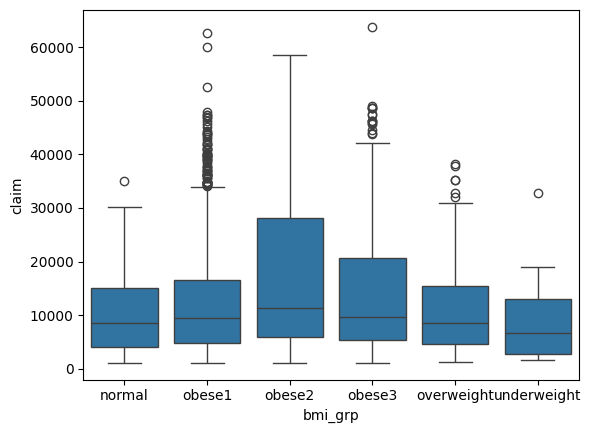

In [226]:
sns.boxplot(data=df,x='bmi_grp',y='claim')

<Axes: xlabel='bmi_grp', ylabel='claim'>

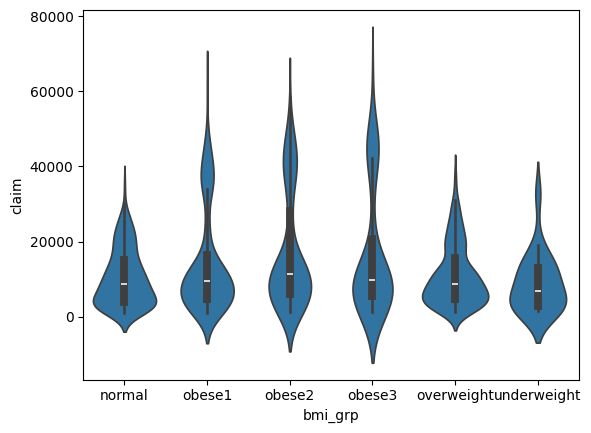

In [227]:
sns.violinplot(data=df,x='bmi_grp',y='claim')

# TRIVARIATE ANALYSIS BETWEEN BP GRP CLAIM AND SMOKER
- Smoking status appears to be the strongest factor associated with claim amount. Across all blood pressure groups, smokers exhibit substantially higher claims than non-smokers. However, claim amounts also tend to increase with blood pressure, particularly among smokers, suggesting that very high blood pressure may contribute additional risk beyond smoking alone

<Axes: xlabel='bp_group', ylabel='claim'>

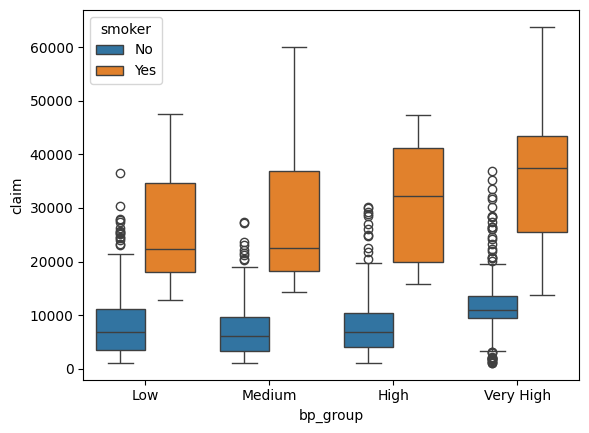

In [228]:
sns.boxplot(data=df, x='bp_group', y='claim', hue='smoker')

# TRIVARAITE ANALYSIS BW BMIGRP CLAIM AND SMOKER 

- Obesity appears to play a role in insurance claims, particularly among smokers. While BMI alone shows only a weak relationship with claim amount, smoker claim distributions increase noticeably across obesity categories, with Obese II and Obese III smokers exhibiting the highest claim amounts. This suggests an interaction between smoking status and BMI

<Axes: xlabel='bmi_grp', ylabel='claim'>

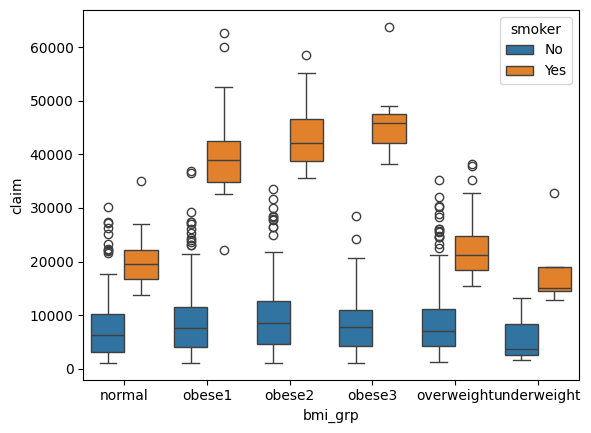

In [230]:
sns.boxplot(data=df, x='bmi_grp', y='claim', hue='smoker')

# MULTIVARIATE ANALYSIS

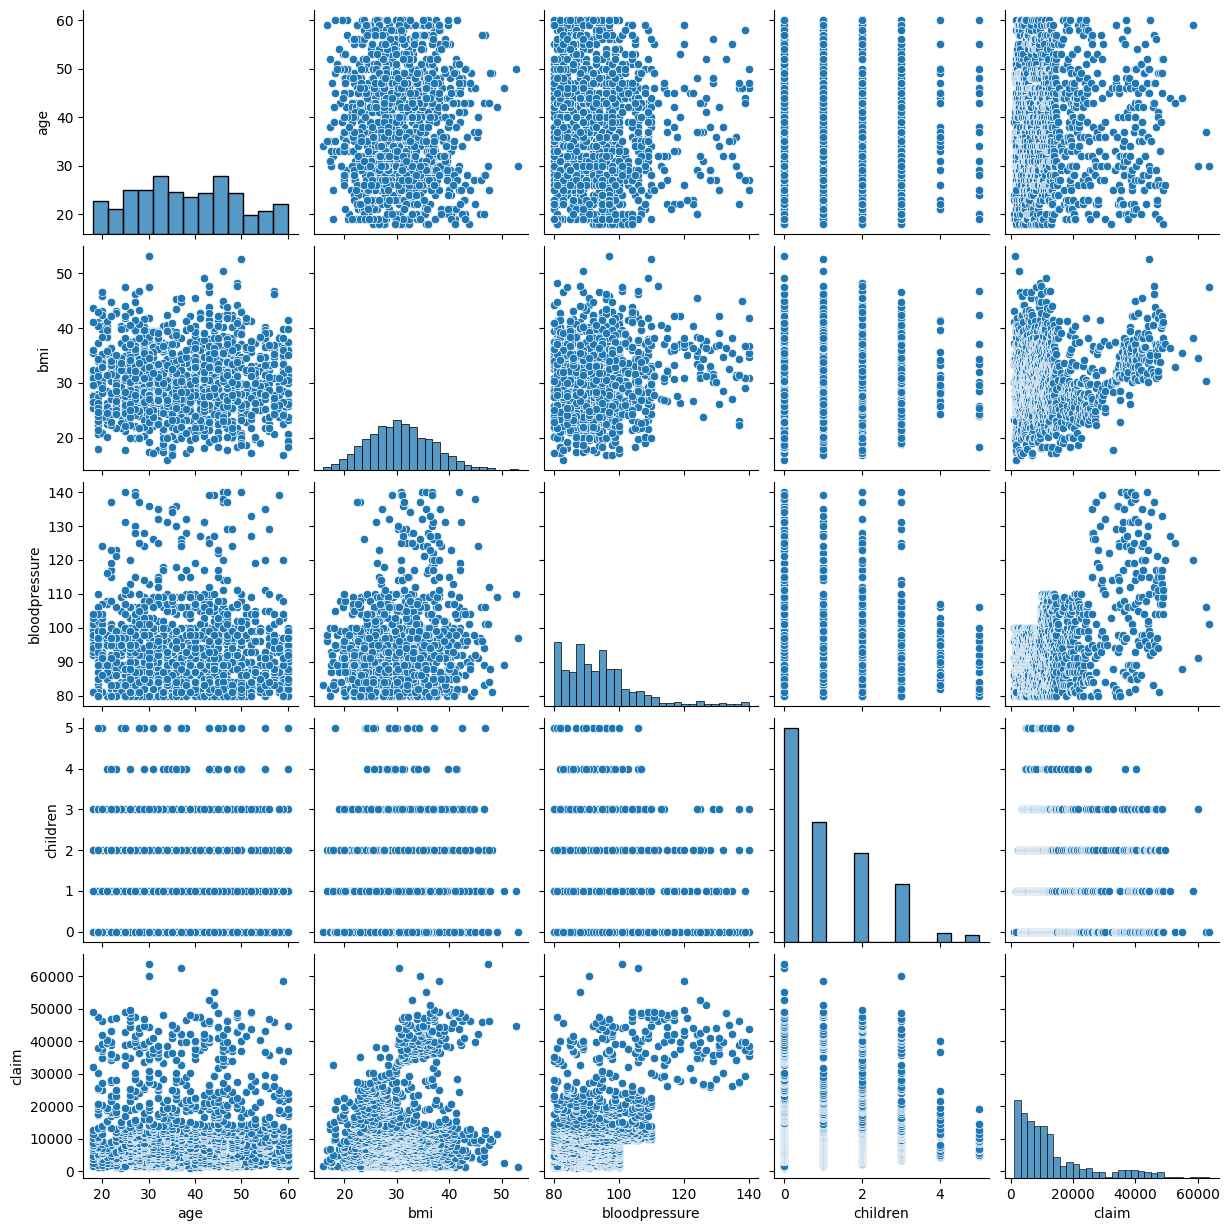

In [234]:
sns.pairplot(df[['age','bmi','bloodpressure','children','claim']])